In [ ]:
import tensorflow_datasets as tfds

# Load the dataset with splits
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HC83IT_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import os

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def format_example(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    return image, label

train_ds = train_ds.map(format_example).batch(BATCH_SIZE).prefetch(1)
val_ds = val_ds.map(format_example).batch(BATCH_SIZE).prefetch(1)


In [ ]:
base_model = VGG16(input_shape=(224, 224, 3),
                   include_top=False,
                   weights='imagenet')
base_model.trainable = False  # Freeze the convolutional base


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 155s 238ms/step - accuracy: 0.8410 - loss: 0.5072 - val_accuracy: 0.9252 - val_loss: 0.1768
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 209ms/step - accuracy: 0.9134 - loss: 0.2065 - val_accuracy: 0.9269 - val_loss: 0.1734
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 209ms/step - accuracy: 0.9268 - loss: 0.1793 - val_accuracy: 0.9366 - val_loss: 0.1543
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 210ms/step - accuracy: 0.9366 - loss: 0.1577 - val_accuracy: 0.9299 - val_loss: 0.1599
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 122s 209ms/step - accuracy: 0.9400 - loss: 0.1426 - val_accuracy: 0.9331 - val_loss: 0.1608


In [ ]:
# Unfreeze some layers of the base model
base_model.trainable = True

# Freeze all layers except the last 4 layers of VGG16
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile the model with a lower learning rate
model.compile(optimizer=optimizers.Adam(1e-5),  # Lower LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
fine_tune_history = model.fit(train_ds,
                              validation_data=val_ds,
                              epochs=5)


Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 152s 250ms/step - accuracy: 0.9564 - loss: 0.1114 - val_accuracy: 0.9488 - val_loss: 0.1239
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 141s 242ms/step - accuracy: 0.9705 - loss: 0.0701 - val_accuracy: 0.9589 - val_loss: 0.1142
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 140s 241ms/step - accuracy: 0.9842 - loss: 0.0422 - val_accuracy: 0.9607 - val_loss: 0.1289
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 141s 242ms/step - accuracy: 0.9898 - loss: 0.0285 - val_accuracy: 0.9589 - val_loss: 0.1506
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 141s 242ms/step - accuracy: 0.9941 - loss: 0.0159 - val_accuracy: 0.9613 - val_loss: 0.1617


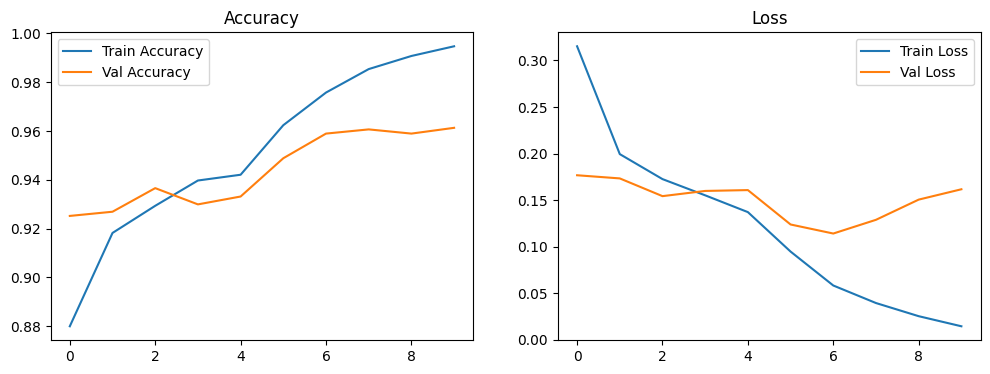

In [ ]:
def plot_history(history, fine_tune_history):
    acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
    val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
    loss = history.history['loss'] + fine_tune_history.history['loss']
    val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history, fine_tune_history)


In [ ]:
'''

✅ 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import os
import tensorflow_datasets as tfds


tensorflow → main deep learning library

ImageDataGenerator → for image augmentation

VGG16 → pre-trained CNN for transfer learning

layers, models, optimizers → to build and train the model

matplotlib.pyplot → to plot images and results

tensorflow_datasets (tfds) → easy access to standard datasets

✅ 2. Load Cats vs Dogs Dataset
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)

Explanation:

tfds.load() → downloads and loads the dataset.

'cats_vs_dogs' → dataset name.

split=['train[:80%]', 'train[80%:]'] →

First 80% of training set → train_ds

Remaining 20% → val_ds (validation set)

with_info=True → returns ds_info containing metadata like:

Number of classes, class names, image shapes

as_supervised=True → returns tuples (image, label) for easy model input

✅ 3. Dataset Characteristics

Each image: varied size, RGB (3 channels)

Labels: 0 = Cat, 1 = Dog

ds_info can be used to check info:

print(ds_info)
print(ds_info.features['label'].names)  # ['Cat', 'Dog']

✅ Next Steps (Typical Workflow)

Resize images to match VGG16 input (224×224×3)

Normalize pixel values (0–1 or -1 to 1)

Batch & prefetch dataset for faster training:

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # normalize
    return image, label

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Use VGG16 as base (with include_top=False) and add custom classifier for 2 classes.

✅ 1. Set Image Size and Batch Size
IMG_SIZE = 224
BATCH_SIZE = 32


IMG_SIZE = 224 → Resize all images to 224×224 pixels to match VGG16 input.

BATCH_SIZE = 32 → Number of images processed in one training step.

✅ 2. Define Preprocessing Function
def format_example(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))  # Resize
    image = tf.cast(image, tf.float32) / 255.0           # Normalize to [0,1]
    return image, label


tf.image.resize() → resizes the image to 224×224

tf.cast(image, tf.float32) → ensures pixel values are float32

/ 255.0 → normalize pixel values from [0, 255] → [0, 1]

Returns processed (image, label) tuple

✅ 3. Apply Preprocessing, Batch, and Prefetch
train_ds = train_ds.map(format_example).batch(BATCH_SIZE).prefetch(1)
val_ds = val_ds.map(format_example).batch(BATCH_SIZE).prefetch(1)


Step-by-step:

map(format_example) → applies preprocessing to every image-label pair in the dataset

batch(BATCH_SIZE) → groups images into batches of size 32

prefetch(1) → loads the next batch while the current batch is being processed, improving GPU utilization and speeding up training

base_model = VGG16(input_shape=(224, 224, 3),
                   include_top=False,
                   weights='imagenet')
Explanation:
VGG16

Loads the pre-trained VGG16 CNN model from Keras.

input_shape=(224, 224, 3)

Specifies the input size:

Height = 224 pixels

Width = 224 pixels

Channels = 3 (RGB)

include_top=False

Excludes the fully connected layers at the top of VGG16.

We only use the convolutional base for feature extraction.

weights='imagenet'

Loads the model pre-trained on ImageNet.

Provides learned feature detectors (edges, textures, shapes).

python
Copy code
base_model.trainable = False  # Freeze the convolutional base
Explanation:
trainable = False → freezes all layers of VGG16.

During training:

Only newly added layers (like dense layers) will update weights.

Pre-trained convolutional layers remain unchanged.

Benefits:

Reduces training time

Prevents overfitting on small datasets

model = models.Sequential([
    base_model,
base_model → the pre-trained VGG16 convolutional base (frozen).

Extracts features from the input images.

python
Copy code
    layers.Flatten(),
Converts the 3D feature maps from VGG16 into a 1D vector.

Needed before passing data to fully connected (Dense) layers.

python
Copy code
    layers.Dense(256, activation='relu'),
Adds a fully connected layer with 256 neurons.

activation='relu' introduces non-linearity so the network can learn complex patterns.

python
Copy code
    layers.Dropout(0.5),
Applies dropout regularization (50%) to reduce overfitting.

Randomly sets 50% of inputs to 0 during training.

python
Copy code
    layers.Dense(1, activation='sigmoid')  # Binary classification
])
Adds the output layer for binary classification (cat vs dog).

activation='sigmoid' → outputs a probability between 0 and 1.

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
Explanation:
optimizer='adam'

Adam is an adaptive learning rate optimizer that combines momentum and RMSProp concepts.

Helps the model converge faster and efficiently.

loss='binary_crossentropy'

Suitable for binary classification tasks (Cat vs Dog).

Measures the difference between predicted probability and true label (0 or 1).

metrics=['accuracy']

Track accuracy during training and validation.

Accuracy = (Number of correct predictions) / (Total predictions)

python
Copy code
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5)
Explanation:
train_ds → training dataset (batched, resized, normalized)

validation_data=val_ds → evaluate model after each epoch on validation set

epochs=5 → run 5 full passes over the training dataset

history → stores the training history including:

history.history['loss'] → training loss per batch/epoch

history.history['accuracy'] → training accuracy per epoch

history.history['val_loss'] → validation loss

history.history['val_accuracy'] → validation accuracy

# Unfreeze some layers of the base model
base_model.trainable = True
Sets the entire VGG16 convolutional base as trainable.

All layers can now have their weights updated during training.

python
Copy code
# Freeze all layers except the last 4 layers of VGG16
for layer in base_model.layers[:-4]:
    layer.trainable = False
Loops through all layers except the last 4.

Keeps most of the pre-trained features frozen, only last few convolutional layers will be updated.

This allows the model to adapt higher-level features to the new dataset while preserving low-level filters (edges, textures).

python
Copy code
# Recompile the model with a lower learning rate
model.compile(optimizer=optimizers.Adam(1e-5),  # Lower LR
              loss='binary_crossentropy',
              metrics=['accuracy'])
Lower learning rate (1e-5) is used during fine-tuning:

Prevents large weight updates from destroying pre-trained features.

Ensures stable fine-tuning.

loss='binary_crossentropy' → still binary classification

metrics=['accuracy'] → track performance

python
Copy code
# Fine-tune the model
fine_tune_history = model.fit(train_ds,
                              validation_data=val_ds,
                              epochs=5)
Train the model again with a small learning rate.

Updates weights of the last 4 layers of VGG16 + fully connected layers.

Stores the fine-tuning history in fine_tune_history for plotting accuracy/loss.

def plot_history(history, fine_tune_history):
Defines a function to plot training and validation metrics.

Takes two arguments:

history → history from initial training

fine_tune_history → history from fine-tuning

python
Copy code
    acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
    val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
    loss = history.history['loss'] + fine_tune_history.history['loss']
    val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']
Combines initial training and fine-tuning metrics:

acc → combined training accuracy

val_acc → combined validation accuracy

loss → combined training loss

val_loss → combined validation loss

Using + concatenates the lists of epochs from both training phases.

python
Copy code
    epochs_range = range(len(acc))
Creates a range object for x-axis (total number of epochs across both phases).

python
Copy code
    plt.figure(figsize=(12, 4))
Initializes a matplotlib figure with width=12, height=4.

python
Copy code
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')
Left subplot: accuracy curves

Plots train vs validation accuracy

Adds legend and title

python
Copy code
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
Right subplot: loss curves

Plots train vs validation loss

Adds legend and title

python
Copy code
    plt.show()
Displays the combined figure with accuracy and loss plots.

python
Copy code
plot_history(history, fine_tune_history)
Calls the function with the initial training history and the fine-tuning history.

Produces a single plot showing the full training process, including fine-tuning, which helps visualize improvements in performance after unfreezing the last layers.

✅ Effect:
You get a clear view of accuracy and loss across both phases, making it easy to compare the impact of fine-tuning on your Cats vs Dogs VGG16 model.


